# Concept spread types × rooting: does the diffusion typology predict how concepts take root in new fields?

This notebook demos the **type × rooting** step of the evaluation artifact *"Checking concept spread types on unseen and medical data"*. The step is `eval.py rooting`, which runs `evalsteps/rooting.py` with helpers from `evalsteps/base.py`.

**Background.** An earlier experiment split emerging OpenAlex concepts into two data-driven diffusion types. It clustered each concept's 3-channel trajectory (subfield entropy, relative strength, active subfields) with DTW k-medoids, k = 2:
- **BROAD**: *broad from the start (rapid interdisciplinary)*;
- **LOCALISED**: stays concentrated in its origin community.

A separate mechanism study (D2) records every **host entry**: the first time a concept appears in a new host subfield *d* in year *e*. For each entry it measures:
- **`A_cont`**: *host share*, the share of the concept's co-occurring partners that are native to the host;
- **`CT`**: *co-transfer*, whether it arrived as a package with its home-field partners;
- **`EST_bin` / `Y_strict`**: whether the concept later *roots* (establishes) in that host. These outcomes exist only for the screen fold; the held-out fold has sealed W1 features only.

**What this step tests** (pre-declared in `rooting_spec.json`):
1. Do BROAD concepts enter hosts with **higher host share** (`A_cont`)? The spec predicts yes.
2. Do BROAD concepts enter with **lower co-transfer** (`CT`)? The spec predicts yes.
3. Exploratory: is host share a stronger predictor of rooting in BROAD concepts (PPML interaction)?

Each question is answered on the screen fold, on the one-time **held-out** fold (W1 only), and pooled. The methods are cluster bootstraps, OLS with host × entry-year fixed effects (`pyfixest`) and a custom PPML.

**Demo data.** The full run used 184 screen concepts (1,740 entries) and 93 held-out concepts (1,097 entries). `mini_demo_data.json` holds a type-stratified subset: 60 screen and 40 held-out concepts. The config cell chooses how many of them to use and how many bootstrap draws to take.

Full-run headline, for reference:
- the adjusted BROAD − LOCALISED gap in `A_cont` is null: −0.0018 on screen, +0.0005 held-out, so the declared prediction is **not supported**;
- `CT` is lower for BROAD: −0.126 on screen, −0.125 held-out, so this prediction **replicates**.

In [1]:
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# numpy, pandas, scipy, matplotlib, numba — pre-installed on Colab, install locally only (Colab's exact versions)
if 'google.colab' not in sys.modules:
    _pip('numpy==2.0.2', 'pandas==2.2.2', 'scipy==1.16.3', 'matplotlib==3.10.0', 'numba==0.60.0')

# pyfixest (fixed-effects OLS), loguru — NOT on Colab, always install
_pip('pyfixest==0.60.0', 'loguru==0.7.3')

In [2]:
# original imports (evalsteps/base.py + evalsteps/rooting.py)
from __future__ import annotations

import hashlib
import json
import math
import os
import sys
from pathlib import Path

import numpy as np
import pandas as pd
from loguru import logger

# additional imports for the notebook
import time
import types
import matplotlib.pyplot as plt

In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/ai-inventor-papers/ai-invention-8892b7-occupancy-is-not-integration-for-new/main/round-4/evaluation-4/demo/mini_demo_data.json"
import json
from pathlib import Path

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception: pass
    local = Path("mini_demo_data.json")
    if local.exists(): return json.loads(local.read_text())
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
data = load_data()
print({k: len(v) for k, v in data.items() if isinstance(v, list)})

{'screen_entries': 690, 'heldout_entries_W1': 584, 'all_main_screen': 788, 'all_main_heldout': 665, 'roles_screen': 863, 'roles_heldout': 574}


## Configuration

These are all the tunable parameters. The original values are in the comments.
- **Concept counts.** The mini file holds 60 screen and 40 held-out concepts, stratified by type. Each count is split half BROAD, half LOCALISED.
- **Bootstrap draws.** They set how precise the confidence intervals are, and they dominate the runtime.

In [5]:
N_SCREEN_CONCEPTS = 60    # concepts used from the screen fold (max 60 in the mini file; original full run: 184)
N_HELDOUT_CONCEPTS = 40   # concepts used from the held-out fold (max 40 in the mini file; original full run: 93)
B_DESC = 2000             # concept-cluster bootstrap draws for per-type descriptives + type difference (original: 2000)
B_ROLE = 1000             # bootstrap draws for host share per lagged role (original: 1000)
PPML_MAXIT = 500          # PPML IRLS max iterations (original: 500)
PPML_TOL = 1e-12          # PPML convergence tolerance (original: 1e-12)

## Shared helpers (`evalsteps/base.py`)

These are copied from `base.py`. Only the workspace path constants were dropped, since no files are read here.
- **Type labels:** the full frozen cluster names and their short forms.
- **Wilson intervals**, for type shares.
- **`cluster_boot_many`:** resamples whole *concepts* with replacement, since entries of the same concept are not independent. It evaluates several statistics on the same resamples.

In [6]:
BROAD = "broad from the start (rapid interdisciplinary)"
LOCAL = "localised"
TYPE_SHORT = {BROAD: "BROAD", LOCAL: "LOCALISED"}
Z = 1.959964


def clean(o):
    if isinstance(o, dict):
        return {str(k): clean(v) for k, v in o.items()}
    if isinstance(o, (list, tuple)):
        return [clean(v) for v in o]
    if isinstance(o, (np.integer,)):
        return int(o)
    if isinstance(o, (np.floating, float)):
        v = float(o)
        return None if not math.isfinite(v) else v
    if isinstance(o, np.bool_):
        return bool(o)
    if isinstance(o, np.ndarray):
        return clean(o.tolist())
    if o is pd.NA or o is pd.NaT:
        return None
    return o


def wilson(k: int, n: int) -> list:
    if n == 0:
        return [None, None]
    p = k / n
    den = 1 + Z * Z / n
    c = (p + Z * Z / (2 * n)) / den
    h = Z * math.sqrt(p * (1 - p) / n + Z * Z / (4 * n * n)) / den
    return [max(0.0, c - h), min(1.0, c + h)]


def share(k: int, n: int) -> dict:
    return dict(k=int(k), n=int(n), share=(k / n) if n else None, wilson_ci=wilson(int(k), int(n)))


def cluster_boot_many(df: pd.DataFrame, stats: dict, cluster: str = "concept_id", B: int = 2000, seed: int = 0) -> dict:
    """Same resamples for several statistics (faster, index-based)."""
    codes, uniq = pd.factorize(df[cluster])
    idx_by = [np.flatnonzero(codes == i) for i in range(len(uniq))]
    rng = np.random.default_rng(seed)
    obs = {k: f(df) for k, f in stats.items()}
    draws = {k: [] for k in stats}
    for _ in range(B):
        pick = rng.integers(0, len(uniq), len(uniq))
        rows = np.concatenate([idx_by[i] for i in pick])
        d = df.iloc[rows]
        for k, f in stats.items():
            v = f(d)
            if v is not None and np.isfinite(v):
                draws[k].append(v)
    return {k: dict(est=obs[k], ci=(np.percentile(draws[k], [2.5, 97.5]).tolist() if draws[k] else [None, None]),
                    B=B, n_clusters=len(uniq), n_rows=len(df)) for k in stats}

## Fast PPML with two-way fixed effects (`ppml.py` from the D2 experiment)

`rooting.py` imports this module from the D2 experiment (`art_2Cd2JJypeGuA`, `src/ppml.py`). The fitting code below is copied verbatim. It is Poisson pseudo-maximum likelihood fitted by IRLS, and it:
- absorbs high-dimensional fixed effects through an exact sparse weighted projection;
- first prunes singleton and all-zero FE levels (separation);
- reports CRV1 (concept-clustered) standard errors with pyfixest's small-sample factor.

The last line registers the functions as a module named `ppml`, so the original `import ppml` statement works unchanged.

In [7]:
def _prune(y: np.ndarray, fes: list[np.ndarray]) -> np.ndarray:
    """Iteratively drop singleton FE levels and FE levels with all-zero outcome (separation)."""
    keep = np.ones(len(y), bool)
    for _ in range(50):
        changed = False
        for f in fes:
            cnt = np.bincount(f[keep], minlength=f.max() + 1)
            sy = np.bincount(f[keep], weights=y[keep], minlength=f.max() + 1)
            bad = (cnt <= 1) | (sy <= 0)
            drop = keep & bad[f]
            if drop.any():
                keep &= ~drop
                changed = True
        if not changed:
            break
    return keep


def _demean(M: np.ndarray, w: np.ndarray, fes: list[np.ndarray]) -> np.ndarray:
    """Exact weighted projection off the FE space: solve (D'WD + eps I) c = D'W M with a sparse LU (D = [D1 D2])."""
    from scipy import sparse
    from scipy.sparse.linalg import splu
    n = len(w)
    rows, cols, off = [], [], 0
    for f in fes:
        rows.append(np.arange(n))
        cols.append(f + off)
        off += int(f.max()) + 1
    D = sparse.csc_matrix((np.ones(n * len(fes)), (np.concatenate(rows), np.concatenate(cols))), shape=(n, off))
    DW = sparse.csc_matrix(D.multiply(w[:, None]))
    A = sparse.csc_matrix(D.T @ DW) + sparse.identity(off, format="csc") * 1e-9
    c = splu(A).solve(np.asarray(DW.T @ M))
    return M - D @ c


def pd_nunique_per_level(f: np.ndarray, g: np.ndarray) -> int:
    """Max number of distinct clusters within any FE level."""
    pairs = np.unique(np.stack([f, g], 1), axis=0)
    return int(np.bincount(pairs[:, 0]).max())


def fit(y: np.ndarray, X: np.ndarray, fes: list[np.ndarray], offset: np.ndarray, cluster: np.ndarray,
        maxit: int = 100, tol: float = 1e-9) -> dict | None:
    keep = _prune(y.astype(float), fes)
    if keep.sum() < X.shape[1] + 5:
        return None
    y, X, off, cl = y[keep].astype(float), X[keep], offset[keep], cluster[keep]
    fes = [np.unique(f[keep], return_inverse=True)[1] for f in fes]
    if np.linalg.matrix_rank(_demean(X, np.ones(len(y)), fes)) < X.shape[1]:
        return None
    mu = np.maximum(y, 0.1 * y.mean() + 1e-3)
    eta = np.log(mu)
    beta = np.zeros(X.shape[1])
    dev_old = np.inf
    for _ in range(maxit):
        z = eta - off + (y - mu) / mu
        M = _demean(np.column_stack([z, X]), mu, fes)
        zt, Xt = M[:, 0], M[:, 1:]
        WX = Xt * mu[:, None]
        beta = np.linalg.solve(Xt.T @ WX, WX.T @ zt)
        resid = zt - Xt @ beta
        eta = z - resid + off  # eta = X b + FE + offset
        eta = np.clip(eta, -30, 30)
        mu = np.exp(eta)
        dev = 2 * np.sum(np.where(y > 0, y * np.log(np.where(y > 0, y, 1) / mu), 0) - (y - mu))
        if abs(dev - dev_old) / (abs(dev) + 0.1) < tol:
            break
        dev_old = dev
    Xt = _demean(X, mu, fes)
    H = Xt.T @ (Xt * mu[:, None])
    Hi = np.linalg.inv(H)
    sc = Xt * (y - mu)[:, None]
    _, g = np.unique(cl, return_inverse=True)
    G = g.max() + 1
    S = np.zeros((G, X.shape[1]))
    np.add.at(S, g, sc)
    n = len(y)
    # small-sample factor as pyfixest CRV1 (fixef_k='nested'): FE levels nested in clusters are not counted
    k_fe = 0
    for f in fes:
        nested = np.all(np.bincount(f, minlength=f.max() + 1) == 0) or (
            pd_nunique_per_level(f, g) <= 1)
        if not nested:
            k_fe += int(f.max()) + 1 - 1
    k = X.shape[1] + k_fe + (1 if k_fe else 0)
    adj = G / (G - 1) * (n - 1) / (n - k) if G > 1 and n > k else 1.0
    V = adj * Hi @ (S.T @ S) @ Hi
    return {"coef": beta, "se": np.sqrt(np.diag(V)), "n": int(n), "G": int(G), "mu": mu, "keep": keep,
            "Xt": Xt, "y": y, "cl": g}


# notebook shim: expose the functions above as module `ppml` so `import ppml` in ppml_interaction works unchanged
ppml = types.ModuleType("ppml")
ppml.fit, ppml._prune, ppml._demean = fit, _prune, _demean
sys.modules["ppml"] = ppml

## Sample definition and controls (`rooting.py`)

The **D2 co-primary sample** keeps host entries that pass four filters:
- `arm == "main"`;
- the right fold;
- `kw5`, meaning at least 5 distinct partners;
- `MAIN`, meaning in the main concept population.

It also drops rows with missing controls. The controls are the D2 event controls: host–origin proximity `prox_od`, relatedness density `RD`, partner-tag count, coverage, author mobility, topic score and so on. `FORBIDDEN` lists the column prefixes that must never appear in the sealed held-out W1 features, because they are outcome or W2 columns.

In [8]:
CTRL_EVENT = ["prox_od", "RD", "log_n_partner_tags", "cov", "demic", "mean_topic_score", "boundary_share", "abstract_share"]
CTRL_SEC = ["mom_d", "log_centrality", "log_W1"]
FORBIDDEN = ("Y_", "EST", "n_w2", "w2_", "present_")


def d2_sample(df: pd.DataFrame, fold: str) -> pd.DataFrame:
    s = df[(df.arm == "main") & (df.fold == fold) & df.kw5 & df.MAIN].copy()
    need = ["A_cont", "CT"] + CTRL_EVENT + CTRL_SEC
    return s.dropna(subset=[c for c in need if c in s.columns]).reset_index(drop=True)

## Per-type descriptives with concept-cluster bootstrap CIs

For each type this computes:
- mean and concept-averaged host share `A_cont`;
- excess anchoring `A_cont − A0_cont`, where A0 is the pre-entry baseline;
- mean co-transfer `CT`;
- the share of *anchored* graft labels;
- on the screen only: `Y_strict`, the rate of `EST_bin` (the concept establishes in the host), and the concept-averaged *rooted share*.

It also computes:
- **Occupancy**, as entries per concept.
- **The BROAD − LOCALISED difference**, with a bootstrap stratified by type.

The only change from the original is that the default `B` comes from the config cell (original 2000).

In [9]:
def descriptives(s: pd.DataFrame, all_main: pd.DataFrame, with_outcomes: bool, B: int = B_DESC) -> dict:
    out = {}
    for t, g in s.groupby("type"):
        stats = {"A_cont_mean": lambda d: d.A_cont.mean(), "A_cont_concept_avg": lambda d: d.groupby("concept_id").A_cont.mean().mean(),
                 "excess_A": lambda d: (d.A_cont - d.A0_cont).mean(), "CT_mean": lambda d: d.CT.mean(),
                 "anchored_share": lambda d: d.anchored.astype(float).mean() if d.anchored.notna().any() else np.nan}
        if with_outcomes:
            stats.update({"Y_strict_mean": lambda d: d.Y_strict.mean(), "Y_pos_share": lambda d: (d.Y_strict > 0).mean(),
                          "EST_rate": lambda d: d.EST_bin.mean(), "rooted_share": lambda d: d.groupby("concept_id").EST_bin.mean().mean()})
        b = cluster_boot_many(g, stats, B=B, seed=1)
        b["A_cont_median"] = float(g.A_cont.median())
        b["n_entries"] = len(g)
        b["n_concepts"] = int(g.concept_id.nunique())
        out[t] = b
    # occupancy: entries per concept, all MAIN kw-any entries and co-primary sample (concepts with 0 entries included)
    occ = {}
    for t in ("BROAD", "LOCALISED"):
        a = all_main[all_main.type == t]
        occ[t] = dict(all_main_entries_per_concept=float(a.groupby("concept_id").size().mean()) if len(a) else None,
                      coprimary_entries_per_concept=float(s[s.type == t].groupby("concept_id").size().mean()) if (s.type == t).any() else None)
    out["occupancy"] = occ
    # type difference (BROAD - LOCALISED) by concept-cluster bootstrap, stratified by type
    diffs = {}
    keys = ["A_cont", "CT"] + (["Y_strict", "EST_bin"] if with_outcomes else [])
    rng = np.random.default_rng(7)
    gb = {t: {c: g for c, g in s[s.type == t].groupby("concept_id")} for t in ("BROAD", "LOCALISED")}
    obs = {k: s[s.type == "BROAD"][k].mean() - s[s.type == "LOCALISED"][k].mean() for k in keys}
    draws = {k: [] for k in keys}
    for _ in range(B):
        m = {}
        for t in ("BROAD", "LOCALISED"):
            cs = list(gb[t])
            pick = rng.integers(0, len(cs), len(cs))
            m[t] = pd.concat([gb[t][cs[i]] for i in pick])
        for k in keys:
            draws[k].append(m["BROAD"][k].mean() - m["LOCALISED"][k].mean())
    for k in keys:
        diffs[k] = dict(diff=obs[k], ci=np.percentile(draws[k], [2.5, 97.5]).tolist())
    out["diff_BROAD_minus_LOCALISED"] = diffs
    return out

## Models (i) and (ii): adjusted type gap with host × entry-year fixed effects

The model is OLS `y ~ BROAD + log_n_partner_tags + RD | d×e`, with *y* = `A_cont` in model (i) and *y* = `CT` in model (ii).
- The fixed effect is host subfield *d* × entry year *e*, so BROAD and LOCALISED entries are compared **within the same host in the same year**.
- Standard errors are CRV1, clustered by concept.
- For pooled data a fold dummy is added.

The coefficient is also reported in SD units of *y*.

In [10]:
def feols(s: pd.DataFrame, y: str) -> dict:
    import pyfixest as pf
    d = s.copy()
    d["BROAD"] = (d.type == "BROAD").astype(float)
    d["dxe"] = d.d.astype(str) + "_" + d.e.astype(str)
    extra = " + C(fold)" if d.fold.nunique() > 1 else ""
    f = pf.feols(f"{y} ~ BROAD + log_n_partner_tags + RD{extra} | dxe", data=d, vcov={"CRV1": "concept_id"})
    t = f.tidy()
    r = t.loc["BROAD"]
    return dict(y=y, n=int(f._N), n_concepts=int(d.concept_id.nunique()), coef=float(r["Estimate"]), se=float(r["Std. Error"]),
                p=float(r["Pr(>|t|)"]), ci=[float(r["2.5%"]), float(r["97.5%"])], sd_y=float(d[y].std()),
                coef_in_sd=float(r["Estimate"]) / float(d[y].std()), fe="host x entry year (d x e)", cluster="concept")

## Model (iii): does host share matter more for rooting in BROAD concepts? (exploratory, screen only)

The model is PPML of `Y_strict`, the later-period host papers that mention the concept.
- **Regressors:** `A_cont`, `A_cont × BROAD`, `CT` and all D2 controls.
- **Fixed effects:** concept, entry year and host.
- **Offset:** `log(n_entry_papers)`.

A second parameterisation puts in `A_cont × LOCAL` and `A_cont × BROAD` separately, which gives an incidence-rate ratio (IRR) per SD of `A_cont` within each type. The type main effect is absorbed by the concept fixed effects.

Only two lines differ from the original. The `sys.path.insert(0, E7/src)` line is gone, since `ppml` is now defined above. `maxit` and `tol` come from the config cell.

In [11]:
def ppml_interaction(s: pd.DataFrame) -> dict:
    import sys
    import ppml  # registered by the PPML cell above (original: sys.path.insert(0, str(E7 / "src")))
    d = s.copy()
    d["BROAD"] = (d.type == "BROAD").astype(float)
    sdA = d.A_cont.std()
    d["A_x_BROAD"] = d.A_cont * d.BROAD
    xv = ["A_cont", "A_x_BROAD", "CT"] + CTRL_EVENT + CTRL_SEC
    fes = [pd.factorize(d.concept_id)[0], pd.factorize(d.e.astype(str))[0], pd.factorize(d.d.astype(str))[0]]
    off = np.log(d.n_entry_papers.astype(float).to_numpy())
    r = ppml.fit(d.Y_strict.to_numpy(float), d[xv].to_numpy(float), fes, off, d.concept_id.to_numpy(), maxit=PPML_MAXIT, tol=PPML_TOL)
    d["A_x_LOCAL"] = d.A_cont * (1 - d.BROAD)
    xv2 = ["A_x_LOCAL", "A_x_BROAD", "CT"] + CTRL_EVENT + CTRL_SEC
    r2 = ppml.fit(d.Y_strict.to_numpy(float), d[xv2].to_numpy(float), fes, off, d.concept_id.to_numpy(), maxit=PPML_MAXIT, tol=PPML_TOL)
    if r is None or r2 is None:
        return dict(note="PPML did not converge")
    from scipy.stats import norm
    bi, sei = float(r["coef"][1]), float(r["se"][1])
    irr = lambda bb, se: dict(coef=float(bb), se=float(se), irr_per_sd=float(np.exp(bb * sdA)),
                              ci=[float(np.exp((bb - 1.96 * se) * sdA)), float(np.exp((bb + 1.96 * se) * sdA))],
                              p=float(2 * norm.sf(abs(bb / se))))
    return dict(n_retained=int(r["n"]), G=int(r["G"]), sd_A_cont=float(sdA), LOCALISED=irr(r2["coef"][0], r2["se"][0]),
                BROAD=irr(r2["coef"][1], r2["se"][1]), interaction_coef=bi, interaction_se=sei,
                interaction_p=float(2 * norm.sf(abs(bi / sei))), fe="concept + e + host (D2 co-primary)",
                note="exploratory; type main effect absorbed by concept FE")

## Host share per lagged community role

The concept's **robust primary community role** in year *e−1* is attached to each entry in year *e*. The role comes from Leiden community detection over 6 seeds: BRIDGE, MIGRANT, STAYER, and so on, or NONROBUST if the seeds disagree. The function then tabulates mean `A_cont`, `CT` and, on the screen, the establishment rate, per role and per Guimerà–Amaral class.

This is descriptive. The only change from the original is that the bootstrap `B` comes from the config cell (original 1000).

In [12]:
def role_host_share(ev: pd.DataFrame, roles: pd.DataFrame, with_outcomes: bool) -> dict:
    r = roles[["concept_id", "year", "role_modal", "robust", "GA_class"]].copy()
    r["role_lag"] = np.where(r.robust, r.role_modal, "NONROBUST")
    r["year"] = r.year + 1  # role in e-1 attaches to entry year e
    m = ev.merge(r.rename(columns={"year": "e"}), on=["concept_id", "e"], how="left")
    m["role_lag"] = m.role_lag.fillna("NO_ROLE_ROW")
    m["GA_class"] = m.GA_class.fillna("NO_ROLE_ROW")
    out = {}
    for by in ("role_lag", "GA_class"):
        tab = {}
        for k, g in m.groupby(by):
            st = {"A_cont": lambda d: d.A_cont.mean(), "CT": lambda d: d.CT.mean()}
            if with_outcomes:
                st["EST_rate"] = lambda d: d.EST_bin.mean()
            b = cluster_boot_many(g, st, B=B_ROLE, seed=3)
            b["n_entries"] = len(g)
            b["n_concepts"] = int(g.concept_id.nunique())
            tab[str(k)] = b
        out[by] = tab
    return out

## Load the demo data into the frames `run()` expects

In the original `run()`, the inputs come from files:
- screen events come from the D2 parquet files, joined to graft labels and to the frozen typology assignments;
- the held-out W1 features pass a sha256 check and an assertion that no outcome columns are present.

Here the same rows come from `mini_demo_data.json`, which was already joined and filtered to the co-primary sample. The first `N_*_CONCEPTS` concepts are kept per fold, half BROAD and half LOCALISED. The `FORBIDDEN` assertion from `load_heldout_w1()` is still applied to the held-out rows.

In [13]:
def _take(df: pd.DataFrame, n: int) -> list:
    # type-stratified: first n/2 concepts (sorted id) of each type
    out = []
    for t in ("BROAD", "LOCALISED"):
        out += sorted(df[df.type == t].concept_id.unique())[: max(1, n // 2)]
    return out

ev = pd.DataFrame(data["screen_entries"])
cs_s = _take(ev, N_SCREEN_CONCEPTS)
ev = ev[ev.concept_id.isin(cs_s)].reset_index(drop=True)
all_main_s = pd.DataFrame(data["all_main_screen"]).query("concept_id in @cs_s")
roles_s = pd.DataFrame(data["roles_screen"])

h = pd.DataFrame(data["heldout_entries_W1"])
bad = [c for c in h.columns if c.startswith(FORBIDDEN)]
assert not bad, f"outcome/W2 columns present in held-out features: {bad}"
cs_h = _take(h, N_HELDOUT_CONCEPTS)
h = h[h.concept_id.isin(cs_h)].reset_index(drop=True)
all_main_h = pd.DataFrame(data["all_main_heldout"]).query("concept_id in @cs_h")
roles_h = pd.DataFrame(data["roles_heldout"])

print(f"screen: {ev.concept_id.nunique()} concepts, {len(ev)} entries | held-out: {h.concept_id.nunique()} concepts, {len(h)} entries")
print(ev.groupby("type").concept_id.nunique().to_dict(), h.groupby("type").concept_id.nunique().to_dict())

screen: 60 concepts, 690 entries | held-out: 40 concepts, 584 entries
{'BROAD': 30, 'LOCALISED': 30} {'BROAD': 20, 'LOCALISED': 20}


## Screen fold: descriptives and models (i), (ii), (iii)

This is the body of the original `run()` for the screen fold. The only differences are the removed file writes (`to_parquet`, `sha256`). Screen rows are **descriptive**, because this fold was already used to design the typology.

In [14]:
t0 = time.time()
s = d2_sample(ev, "screen")
s = s[s.type.notna()].reset_index(drop=True)
out = dict(screen=dict(label="descriptive (screened data)", n_entries=len(s),
           n_concepts=int(s.concept_id.nunique()), n_unmatched_concepts=int(d2_sample(ev, "screen").type.isna().sum())))
out["screen"]["descriptives"] = descriptives(s, all_main_s, True)
out["screen"]["model_i_Acont"] = feols(s, "A_cont")
out["screen"]["model_ii_CT"] = feols(s, "CT")
try:
    out["screen"]["model_iii_ppml"] = ppml_interaction(s)
except (KeyError, ValueError, np.linalg.LinAlgError) as e:
    logger.exception("PPML interaction failed")
    out["screen"]["model_iii_ppml"] = dict(error=repr(e))
# A_cont quintile x type EST rate (for F2b)
s["A_q"] = pd.qcut(s.A_cont.rank(method="first"), 5, labels=[1, 2, 3, 4, 5]).astype(int)
out["screen"]["EST_by_Aq_type"] = {f"{t}_q{q}": dict(n=len(g), EST_rate=float(g.EST_bin.mean())) for (t, q), g in s.groupby(["type", "A_q"])}
out["screen"]["host_share_per_role"] = role_host_share(s, roles_s, True)
print(f"screen done in {time.time() - t0:.1f}s")
print(json.dumps(clean({k: out["screen"][k] for k in ("model_i_Acont", "model_ii_CT")}), indent=1))

/tmp/aii_nb_test_envs/art_mu0h0npvNX_u-e586c4297131/lib/python3.12/site-packages/pyfixest/estimation/formula/model_matrix.py:151: UserWarning: 339 singleton fixed effect(s) dropped from the model.
  warnings.warn(
/tmp/aii_nb_test_envs/art_mu0h0npvNX_u-e586c4297131/lib/python3.12/site-packages/pyfixest/estimation/formula/model_matrix.py:151: UserWarning: 339 singleton fixed effect(s) dropped from the model.
  warnings.warn(


screen done in 12.6s
{
 "model_i_Acont": {
  "y": "A_cont",
  "n": 351,
  "n_concepts": 60,
  "coef": -0.001879587419302322,
  "se": 0.007173866370622074,
  "p": 0.794333379259146,
  "ci": [
   -0.01626854116312308,
   0.012509366324518436
  ],
  "sd_y": 0.05269329600346243,
  "coef_in_sd": -0.03567033307574489,
  "fe": "host x entry year (d x e)",
  "cluster": "concept"
 },
 "model_ii_CT": {
  "y": "CT",
  "n": 351,
  "n_concepts": 60,
  "coef": -0.1119506690815894,
  "se": 0.038730915265375115,
  "p": 0.0055641613663761635,
  "ci": [
   -0.18963504727011127,
   -0.034266290893067555
  ],
  "sd_y": 0.26789313192605496,
  "coef_in_sd": -0.4178930168037698,
  "fe": "host x entry year (d x e)",
  "cluster": "concept"
 }
}


## Held-out fold (W1 only): the out-of-sample test

This fold was opened **once**, and only its W1 features are used, with no rooting outcomes. The procedure:
1. Refit the descriptives and models (i) and (ii).
2. Check the pre-declared rule: the prediction *holds out of sample* if the held-out BROAD coefficient in (i) has the screen's sign **and** its 95% CI excludes 0.
3. Refit on the screen and held-out rows pooled, with a fold fixed effect added.

In [15]:
t0 = time.time()
fold_h = h.fold.iloc[0]
sh = d2_sample(h, fold_h)
n_unm = int(sh.type.isna().sum())
sh = sh[sh.type.notna()].reset_index(drop=True)
ho = dict(label="held-out W1 (confirmatory in spirit: association)", fold_value=fold_h, n_entries=len(sh),
          n_concepts=int(sh.concept_id.nunique()), n_entries_without_type=n_unm)
ho["descriptives"] = descriptives(sh, all_main_h, False)
ho["model_i_Acont"] = feols(sh, "A_cont")
ho["model_ii_CT"] = feols(sh, "CT")
sc = out["screen"]["model_i_Acont"]
hi = ho["model_i_Acont"]
ho["prediction_holds"] = bool(np.sign(hi["coef"]) == np.sign(sc["coef"]) and (hi["ci"][0] > 0 or hi["ci"][1] < 0))
ho["prediction_direction_declared"] = "BROAD higher A_cont (coef > 0)"
ho["declared_direction_confirmed"] = bool(hi["coef"] > 0 and hi["ci"][0] > 0)
ho["host_share_per_role"] = role_host_share(sh, roles_h, False)
out["heldout"] = ho
pool = pd.concat([s.assign(fold="screen"), sh.assign(fold="heldout")], ignore_index=True)
out["pooled_W1"] = dict(n_entries=len(pool), n_concepts=int(pool.concept_id.nunique()), model_i_Acont=feols(pool, "A_cont"),
                        model_ii_CT=feols(pool, "CT"))
out = clean(out)  # original: write_json(RES / "rooting.json", out)
print(f"held-out + pooled done in {time.time() - t0:.1f}s")
print({k: ho[k] for k in ("prediction_holds", "declared_direction_confirmed")})

/tmp/aii_nb_test_envs/art_mu0h0npvNX_u-e586c4297131/lib/python3.12/site-packages/pyfixest/estimation/formula/model_matrix.py:151: UserWarning: 354 singleton fixed effect(s) dropped from the model.
  warnings.warn(
/tmp/aii_nb_test_envs/art_mu0h0npvNX_u-e586c4297131/lib/python3.12/site-packages/pyfixest/estimation/formula/model_matrix.py:151: UserWarning: 354 singleton fixed effect(s) dropped from the model.
  warnings.warn(


held-out + pooled done in 7.4s
{'prediction_holds': False, 'declared_direction_confirmed': False}


/tmp/aii_nb_test_envs/art_mu0h0npvNX_u-e586c4297131/lib/python3.12/site-packages/pyfixest/estimation/formula/model_matrix.py:151: UserWarning: 438 singleton fixed effect(s) dropped from the model.
  warnings.warn(
/tmp/aii_nb_test_envs/art_mu0h0npvNX_u-e586c4297131/lib/python3.12/site-packages/pyfixest/estimation/formula/model_matrix.py:151: UserWarning: 438 singleton fixed effect(s) dropped from the model.
  warnings.warn(


## Results

The table and figures summarise the step's headline numbers on the demo subset, next to the full-run values from `eval_out.json`. With far fewer concepts and bootstrap draws the confidence intervals are wider. The direction of the `CT` gap is the effect to look for.

Adjusted BROAD - LOCALISED gap (OLS, host x entry-year FE, CRV1 by concept)
population outcome  n_entries  n_concepts  coef_BROAD   ci_lo   ci_hi      p  coef_in_sd  full_run_coef
    screen  A_cont        351          60     -0.0019 -0.0163  0.0125 0.7943     -0.0357        -0.0018
    screen      CT        351          60     -0.1120 -0.1896 -0.0343 0.0056     -0.4179        -0.1260
   heldout  A_cont        230          40      0.0147 -0.0118  0.0412 0.2683      0.2808         0.0005
   heldout      CT        230          40     -0.1835 -0.3152 -0.0518 0.0076     -0.6568        -0.1250
 pooled_W1  A_cont        836         100      0.0017 -0.0081  0.0115 0.7275      0.0328            NaN
 pooled_W1      CT        836         100     -0.0940 -0.1479 -0.0402 0.0008     -0.3441        -0.1090

Per-type descriptives (mean [95% cluster-bootstrap CI])
population      type  n_concepts  n_entries  entries_per_concept_all_MAIN          A_cont_mean              CT_mean             EST_rate   

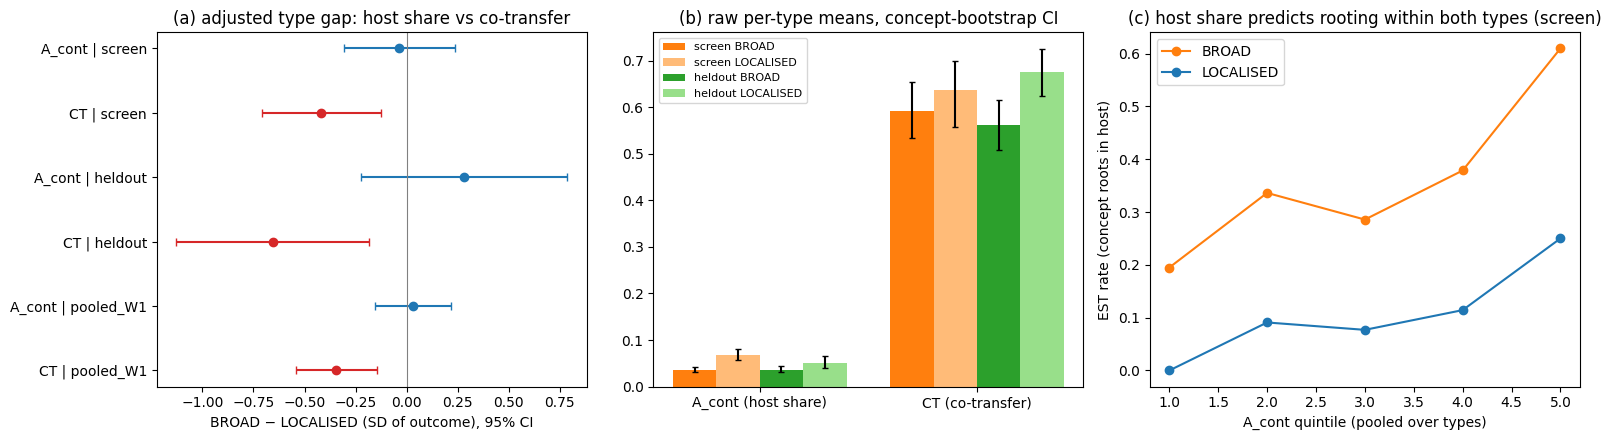

In [16]:
FULL = {  # full-run reference (eval_out.json / README of the evaluation artifact)
    ("screen", "A_cont"): -0.0018, ("heldout", "A_cont"): 0.0005, ("pooled_W1", "A_cont"): None,
    ("screen", "CT"): -0.126, ("heldout", "CT"): -0.125, ("pooled_W1", "CT"): -0.109}
rows = []
for pop in ("screen", "heldout", "pooled_W1"):
    for y, key in (("A_cont", "model_i_Acont"), ("CT", "model_ii_CT")):
        m = out[pop][key]
        rows.append(dict(population=pop, outcome=y, n_entries=m["n"], n_concepts=m["n_concepts"], coef_BROAD=m["coef"],
                         ci_lo=m["ci"][0], ci_hi=m["ci"][1], p=m["p"], coef_in_sd=m["coef_in_sd"], full_run_coef=FULL[(pop, y)]))
res = pd.DataFrame(rows)
pd.set_option("display.width", 200)
print("Adjusted BROAD - LOCALISED gap (OLS, host x entry-year FE, CRV1 by concept)")
print(res.round(4).to_string(index=False))

print("\nPer-type descriptives (mean [95% cluster-bootstrap CI])")
drows = []
for pop in ("screen", "heldout"):
    D = out[pop]["descriptives"]
    for t in ("BROAD", "LOCALISED"):
        r = dict(population=pop, type=t, n_concepts=D[t]["n_concepts"], n_entries=D[t]["n_entries"],
                 entries_per_concept_all_MAIN=round(D["occupancy"][t]["all_main_entries_per_concept"], 1))
        for k in ("A_cont_mean", "CT_mean", "EST_rate", "rooted_share"):
            if k in D[t]:
                r[k] = f'{D[t][k]["est"]:.3f} [{D[t][k]["ci"][0]:.3f}, {D[t][k]["ci"][1]:.3f}]'
        drows.append(r)
print(pd.DataFrame(drows).fillna("-").to_string(index=False))

pp = out["screen"]["model_iii_ppml"]
if "BROAD" in pp:
    print(f'\nPPML (screen, exploratory): A_cont IRR per SD  BROAD {pp["BROAD"]["irr_per_sd"]:.2f} {np.round(pp["BROAD"]["ci"], 2)}'
          f'  LOCALISED {pp["LOCALISED"]["irr_per_sd"]:.2f} {np.round(pp["LOCALISED"]["ci"], 2)}  interaction p = {pp["interaction_p"]:.3f}'
          f'   (full run: 1.36 vs 1.16, p = 0.11)')
else:
    print("\nPPML:", pp)
print("\nHeld-out rule for the declared A_cont prediction:",
      {k: out["heldout"][k] for k in ("prediction_holds", "declared_direction_confirmed")})

fig, ax = plt.subplots(1, 3, figsize=(16, 4.5))
# (a) forest plot of adjusted BROAD coefficients (in SD of y)
lab, est, lo, hi_, col = [], [], [], [], []
for _, r in res.iterrows():
    sd = r.coef_BROAD / r.coef_in_sd if r.coef_in_sd else 1.0
    lab.append(f"{r.outcome} | {r.population}"); est.append(r.coef_in_sd); lo.append(r.ci_lo / sd); hi_.append(r.ci_hi / sd)
    col.append("#1f77b4" if r.outcome == "A_cont" else "#d62728")
yy = np.arange(len(lab))[::-1]
for e_, y_, l_, h_, c_ in zip(est, yy, lo, hi_, col):
    ax[0].errorbar([e_], [y_], xerr=[[e_ - l_], [h_ - e_]], fmt="o", color=c_, capsize=3)
ax[0].axvline(0, color="grey", lw=0.8); ax[0].set_yticks(yy); ax[0].set_yticklabels(lab)
ax[0].set_xlabel("BROAD − LOCALISED (SD of outcome), 95% CI"); ax[0].set_title("(a) adjusted type gap: host share vs co-transfer")
# (b) raw per-type means of A_cont and CT with bootstrap CIs
w = 0.2
for j, (pop, t) in enumerate([("screen", "BROAD"), ("screen", "LOCALISED"), ("heldout", "BROAD"), ("heldout", "LOCALISED")]):
    D = out[pop]["descriptives"][t]
    vals = [D["A_cont_mean"], D["CT_mean"]]
    x = np.arange(2) + (j - 1.5) * w
    ax[1].bar(x, [v["est"] for v in vals], w, yerr=[[v["est"] - v["ci"][0] for v in vals], [v["ci"][1] - v["est"] for v in vals]],
              capsize=2, label=f"{pop} {t}", color=["#ff7f0e", "#ffbb78", "#2ca02c", "#98df8a"][j])
ax[1].set_xticks([0, 1]); ax[1].set_xticklabels(["A_cont (host share)", "CT (co-transfer)"]); ax[1].legend(fontsize=8)
ax[1].set_title("(b) raw per-type means, concept-bootstrap CI")
# (c) EST rate by A_cont quintile x type (screen)
q = out["screen"]["EST_by_Aq_type"]
for t, c in (("BROAD", "#ff7f0e"), ("LOCALISED", "#1f77b4")):
    xs = [i for i in range(1, 6) if f"{t}_q{i}" in q]
    ax[2].plot(xs, [q[f"{t}_q{i}"]["EST_rate"] for i in xs], "o-", color=c, label=t)
ax[2].set_xlabel("A_cont quintile (pooled over types)"); ax[2].set_ylabel("EST rate (concept roots in host)")
ax[2].set_title("(c) host share predicts rooting within both types (screen)"); ax[2].legend()
plt.tight_layout(); plt.show()